# 신용거래 이상탐지 데이터 다루기



## 프로젝트 수행 방법
이번 프로젝트에서 사용할 데이터 이름은 fraud.csv입니다.

신용카드 이상감지 모델을 만들기 위한 데이터이며, is_fraud가 사기거래 여부를 나타내는 변수입니다.

Day 1, 2, 3에서 배운 내용을 모두 동원하여, 최종적으로 사기거래 여부를 예측하기 위한 데이터를 준비해보세요.

만약 이전에 배웠던 내용이 익숙하지 않다면 이전 노드를 다시 한번 복습해 주세요. 🤗

### Step 1. 이것만큼은 꼭 해보세요!
프로젝트에 정답은 없습니다. 배우신 내용을 토대로 자유롭게 데이터를 정제/변환하시되, 아래 내용만큼은 반드시 실습해봅시다.

사기거래 여부를 예측하는 데 불필요한 컬럼을 제거합니다.
최소 2개 이상의 새로운 피처(변수)를 생성해봅시다.   
[힌트] 구매 금액, 시간 등의 변수를 이용할 수 있습니다.



### Step 2. 이런것도 해볼 수 있어요!
자유롭게 실습을 해보시고, 여유가 되면 아래의 내용도 실습해보세요.

강의의 범위를 벗어나는 개념이 필요할 수 있으니, 인터넷 검색도 적극 활용해보세요.

데이터의 위도/경도 정보를 활용해볼 수 있을까요?
통계적 관점으로 접근하여 유용한 변수를 만들어낼 수 있을까요?

### 평가기준
1. 컬럼 이름의 변경이 명확하게 반영되어 있고, 다양한 방법으로 효과적인 결측치 처리를 진행할수 있는가?
2. 데이터의 이상치를 감지하여 수정하고 수정후 데이터의 일관성이 유지되며 품질 또한 향상 되었는가?
3. 추가적인 변수를 창의적으로 생성하고 유용하게 데이터 분석에 기여 하였는가?

# 실습시작

## 1. 프로젝트 목표 설정

✔ 우리가 예측하려는 게 무엇인가?  
✔ 이진 분류인가? 회귀인가?  
✔ 비즈니스 목표는 무엇인가?  

<span style="color: #1877d7ff; font-weight: bold;">본 프로젝트의 목표는 카드 거래 정보를 기반으로<br>
해당 거래가 사기일 확률을 예측하는 이진 분류 문제이다.</span>

* Recall(재현율) 중요 - “사기를 얼마나 놓치지 않았는가?”

* Precision도(정밀도) 중요- “사기라고 한 게 얼마나 정확한가?”

## 2.데이터 살펴보기 (데이터 이해)

✔ 컬럼 의미 파악  
✔ 타겟 변수 분포 확인   
✔ 데이터 크기 확인  
✔ 결측치 / 이상치 존재 여부   

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
cc_df = pd.read_csv('../00_Dataset/fraud.csv')

In [3]:
pd.set_option('display.max_columns', 50)

In [4]:
cc_df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,NJ,7208,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,NJ,7060,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,MI,48174,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,LA,70808,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0


In [5]:
cc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  491134 non-null  object 
 1   cc_num                 491134 non-null  int64  
 2   merchant               491134 non-null  object 
 3   category               491134 non-null  object 
 4   amt                    491134 non-null  float64
 5   first                  491134 non-null  object 
 6   last                   491134 non-null  object 
 7   gender                 491134 non-null  object 
 8   street                 491134 non-null  object 
 9   city                   491134 non-null  object 
 10  state                  491134 non-null  object 
 11  zip                    491134 non-null  int64  
 12  lat                    491134 non-null  float64
 13  long                   491134 non-null  float64
 14  city_pop               491134 non-nu

In [6]:
cc_df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,4.911340e+05,491134.000000,491134.000000,491134.000000,491134.000000,4.911340e+05,4.911340e+05,491134.000000,491134.000000,491134.000000
mean,3.706013e+17,69.050120,50770.532384,37.931230,-90.495619,1.213922e+05,1.358730e+09,37.930272,-90.495411,0.002533
std,1.260229e+18,160.322867,26854.947965,5.341193,12.990732,3.725751e+05,1.819402e+07,5.372986,13.004100,0.050264
min,5.038744e+11,1.000000,1843.000000,24.655700,-122.345600,4.600000e+01,1.325376e+09,23.655789,-123.345106,0.000000
25%,2.131124e+14,8.960000,28405.000000,33.746700,-97.235100,1.228000e+03,1.343087e+09,33.781388,-96.984814,0.000000
50%,3.531130e+15,42.170000,49628.000000,38.507200,-87.591700,5.760000e+03,1.357257e+09,38.545124,-87.573441,0.000000
75%,4.653879e+15,80.330000,75048.000000,41.520500,-80.731000,5.083500e+04,1.374626e+09,41.624294,-80.685567,0.000000
max,4.956829e+18,25086.940000,99323.000000,48.887800,-69.965600,2.906700e+06,1.388534e+09,49.887523,-68.965624,1.000000


In [7]:
cc_df['is_fraud'].value_counts()

is_fraud
0    489890
1      1244
Name: count, dtype: int64

컬럼 정의

| 컬럼명                   | 의미                          | 데이터 유형            | 분석 관점에서의 역할             |
| --------------------- | --------------------------- | ----------------- | ----------------------- |
| trans_date_trans_time | 거래 발생 날짜 및 시간               | 날짜/시간 (현재 object) | 시간대 분석, 요일 패턴, 심야 거래 탐지 |
| cc_num                | 신용카드 번호 (고객 ID 역할)          | 식별자 (int)         | 고객 단위 그룹 분석             |
| merchant              | 가맹점 이름                      | 범주형               | 특정 가맹점 Fraud 비율 분석      |
| category              | 거래 카테고리 (예: grocery, gas 등) | 범주형               | 카테고리별 위험도 분석            |
| amt                   | 거래 금액                       | 연속형               | 이상치 탐지, 금액 기반 Fraud     |
| first                 | 고객 이름                       | 식별자               | 분석에 불필요 (개인정보)          |
| last                  | 고객 성                        | 식별자               | 분석에 불필요                 |
| gender                | 성별                          | 범주형               | 성별별 Fraud 패턴 분석         |
| street                | 주소                          | 식별자               | 지리 분석용 변환 가능            |
| city                  | 도시                          | 범주형               | 지역별 Fraud 분석            |
| state                 | 주(State)                    | 범주형               | 지역 특성 분석                |
| zip                   | 우편번호                        | 범주형/수치형           | 지역 밀집도 분석               |
| lat                   | 고객 위도                       | 연속형               | 거리 계산, 공간 분석            |
| long                  | 고객 경도                       | 연속형               | 공간 분석                   |
| city_pop              | 도시 인구                       | 수치형               | 인구 대비 Fraud 비율          |
| job                   | 직업                          | 범주형               | 직업군별 위험도 분석             |
| dob                   | 생년월일                        | 날짜                | 나이 계산 후 변수 생성           |
| trans_num             | 거래 고유 번호                    | 식별자               | 모델링에 사용 안 함             |
| unix_time             | 거래 발생 시간 (유닉스 타임)           | 수치형               | 시간 간격 분석                |
| merch_lat             | 가맹점 위도                      | 연속형               | 고객-가맹점 거리 계산            |
| merch_long            | 가맹점 경도                      | 연속형               | 거리 기반 Fraud 탐지          |
| is_fraud              | Fraud 여부 (0=정상,1=사기)        | 타겟 변수             | 예측 대상                   |


## 3️.EDA (탐색적 데이터 분석)

✔ 수치형 분포 확인   
✔ 범주형별 타겟 비율   
✔ 상관관계   
✔ 시간/공간 패턴   

어떤 변수가 사기거래와 관련이 있을까?   
is_fraud에서 1이 나온 항목 위주로 보자

---
이상거래란 무엇일까?   
카드 정보가 유출된 경우  
누군가 내 카드로 몰래 결제한 경우    
해외 사이트에서 갑자기 결제 발생  
내가 가지 않은 지역에서 결제 

고객이 “이거 내가 한 거래 아니에요” 신고  

카드사 조사  
부정 사용으로 확정

→ 그 거래가 is_fraud = 1

<span style="color: #1877d7ff; font-weight: bold;">그러므로...  <br> 
고객이 신고한 케이스가 어떤 분포에서 어떤 패턴으로 확인되는지 EDA과정을 통해서 알아보자! </span> 


In [8]:
# fraud=1 데이터만 추출

fraud_df = cc_df[cc_df['is_fraud'] == 1].copy()

print("전체 데이터 수:", len(cc_df))
print("Fraud 데이터 수:", len(fraud_df))
print("Fraud 비율:", len(fraud_df) / len(cc_df))

전체 데이터 수: 491134
Fraud 데이터 수: 1244
Fraud 비율: 0.0025329136243876418


In [9]:
# 기본 통계 확인

fraud_df.describe()

# 여기서 카드넘버는 의미없음 나중에 제거할것!

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.244000e+03,1244.000000,1244.000000,1244.000000,1244.000000,1.244000e+03,1.244000e+03,1244.000000,1244.000000,1244.0
mean,3.802642e+17,477.958328,49169.089228,38.018846,-89.781168,7.976371e+04,1.355786e+09,38.027885,-89.794773,1.0
std,1.273204e+18,398.229485,26821.464413,5.328383,12.540186,2.592555e+05,1.823747e+07,5.337767,12.573992,0.0
min,5.038744e+11,6.380000,1843.000000,24.655700,-122.345600,4.600000e+01,1.326330e+09,23.722663,-123.130516,1.0
25%,2.131124e+14,22.895000,28253.750000,34.032600,-96.601200,8.950000e+02,1.338170e+09,34.057762,-96.518615,1.0
50%,3.527537e+15,334.750000,48174.000000,38.893800,-86.790400,4.542000e+03,1.356657e+09,38.756641,-87.271420,1.0
75%,4.642255e+15,865.385000,72165.000000,41.606000,-80.307000,3.423875e+04,1.371855e+09,41.728511,-80.511924,1.0
max,4.956829e+18,1371.810000,99323.000000,48.887800,-69.965600,2.906700e+06,1.387667e+09,49.579889,-69.006486,1.0


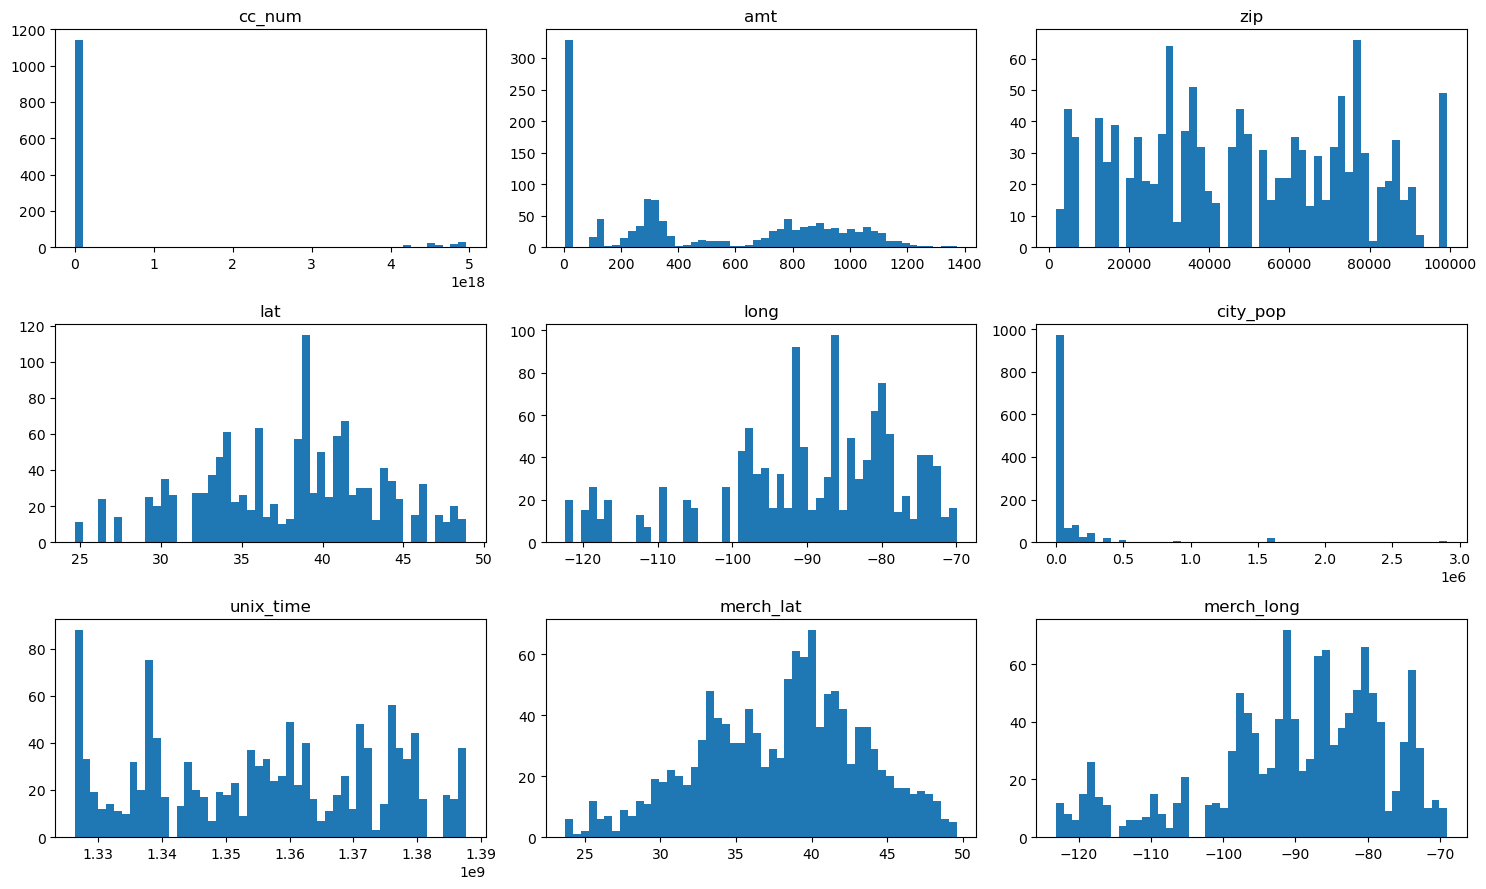

In [10]:
# 주요 변수 분포 확인 (숫자형 변수 기준)

import matplotlib.pyplot as plt
import math

numeric_cols = fraud_df.select_dtypes(include=['int64', 'float64']).columns.drop('is_fraud')

n = len(numeric_cols)
cols = 3  # 한 줄에 몇 개 넣을지
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3*rows))

axes = axes.flatten()  # 2D → 1D로 변환

for i, col in enumerate(numeric_cols):
    axes[i].hist(fraud_df[col], bins=50)
    axes[i].set_title(col)

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
cols = 3 
# → 한 줄에 3개씩 배치

figsize=(5*cols, 3*rows) 
# → 자동 비율 조정
# flatten() → 인덱싱 편하게
# delaxes() → 빈 그래프 제거

# 더 가로로 붙이고 싶으면
# cols = 4
# 로 바꾸면 됨.





CC_num은 카드 넘버라서 별 의미 없음 - 제거 대상

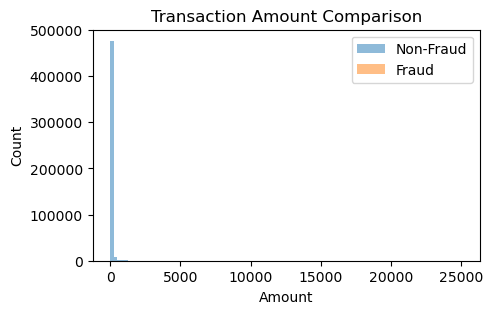

In [11]:
# 정상 거래와 비교 (예: 금액 비교)

non_fraud_df = cc_df[cc_df['is_fraud'] == 0]

plt.figure(figsize=(5, 3))
plt.hist(non_fraud_df['amt'], bins=100, alpha=0.5, label='Non-Fraud')
plt.hist(fraud_df['amt'], bins=100, alpha=0.5, label='Fraud')
plt.legend()
plt.title('Transaction Amount Comparison')
plt.xlabel('Amount')
plt.ylabel('Count')
plt.show()


cc_num → 제거 대상

amt → 정상과 비교 필수

city_pop → 작은 도시 쪽 의심

시간은 hour로 변환 필요

위치는 “거리 계산”이 핵심

In [12]:
# fraud 데이터 상위 금액 확인
fraud_df.sort_values('amt', ascending=False).head(10)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
135833,2019-08-10 22:10:23,3500969075198072,fraud_Metz-Boehm,shopping_pos,1371.81,Kenneth,Sanchez,M,0110 Ashley Forest,Tekoa,WA,99033,47.2271,-117.0819,895,Clothing/textile technologist,1999-05-31,20cf5453224328229e06ae7b4df10302,1344636623,47.065996,-116.262297,1
7933,2019-01-18 23:20:16,4586810168620942,fraud_Pouros-Conroy,shopping_pos,1334.07,Michelle,Gregory,F,6983 Carrillo Isle,Edisto Island,SC,29438,32.5486,-80.3070,2408,"Sales professional, IT",1997-07-05,f0c086495d403024ce6d30f715713319,1326928816,31.615611,-79.702908,1
316777,2020-05-14 23:53:49,4745996322265,"fraud_Kuhic, Bins and Pfeffer",shopping_net,1276.77,Carrie,Washington,F,6114 Adams Harbor Suite 096,Kingsford Heights,IN,46346,41.4802,-86.6919,1423,"Psychologist, forensic",1998-10-07,42b5333784b7efcb3216cc606be17508,1368575629,42.174728,-86.972444,1
75667,2019-05-20 23:09:59,2720433095629877,"fraud_Stanton, Jakubowski and Baumbach",shopping_net,1262.19,Mark,Wood,M,854 Walker Dale Suite 488,Bowdoin,ME,4287,44.0575,-69.9656,3224,"Engineer, electronics",1997-08-22,dffe9a4375a6e74c2b9c4502bd09bcce,1337555399,43.879003,-70.439097,1
311971,2020-05-06 23:11:57,4536996888716062123,fraud_Fisher Inc,shopping_net,1253.93,Nathan,Mendoza,M,767 Adam Mill Apt. 115,Espanola,NM,87533,35.9866,-106.0654,18408,Historic buildings inspector/conservation officer,1972-07-18,2cba079a307eca2f8d34d92ddadb6783,1367881917,35.190482,-105.604155,1
227349,2019-12-17 12:17:00,30273037698427,"fraud_Bins, Balistreri and Beatty",shopping_pos,1234.22,Andrew,Patterson,M,06959 Stephen Branch Suite 246,Thida,AR,72165,35.5762,-91.4539,111,Careers information officer,2000-06-13,11e93b78264202b6f52a39cdb7a3c805,1355746620,34.754466,-91.076240,1
79608,2019-05-26 23:44:45,2242542703101233,"fraud_Roob, Conn and Tremblay",shopping_pos,1228.27,Samuel,Jenkins,M,43235 Mckenzie Views Apt. 837,Westport,KY,40077,38.4921,-85.4524,564,Pensions consultant,1996-04-10,8bc2d5887d9667102ec50426b3b9eba8,1338075885,38.049332,-84.467480,1
62314,2019-04-28 22:27:23,4587657402165341815,"fraud_Bahringer, Schoen and Corkery",shopping_pos,1224.10,Amber,Lewis,F,6296 John Keys Suite 858,Pembroke Township,IL,60958,41.0646,-87.5917,2135,"Psychotherapist, child",2004-05-08,0cbc1a33f4e5311a9b069bf91512e38e,1335652043,40.131610,-86.607200,1
80587,2019-05-27 23:22:09,2242542703101233,fraud_Hudson-Grady,shopping_pos,1221.91,Samuel,Jenkins,M,43235 Mckenzie Views Apt. 837,Westport,KY,40077,38.4921,-85.4524,564,Pensions consultant,1996-04-10,b6b7538b117d5ffffc55fbbd1c08a256,1338160929,37.898578,-86.413167,1
248085,2020-01-08 22:46:57,6011693194885790,fraud_Goyette Inc,shopping_net,1205.11,Victoria,Fleming,F,2807 Parker Station Suite 080,Stanchfield,MN,55080,45.6675,-93.2433,2607,"Lecturer, further education",1995-12-04,f704d6323f819ec086cbbed1139f2acb,1357685217,45.723117,-93.823244,1


In [13]:
# 카테고리 변수 분포 확인
fraud_df['category'].value_counts().head(10)


category
shopping_net     242
grocery_pos      216
shopping_pos     134
misc_net         109
gas_transport    101
home              72
kids_pets         68
food_dining       62
personal_care     58
misc_pos          57
Name: count, dtype: int64


misc_pos → 오프라인 기타 소비
misc_net → 온라인 기타 소비

In [14]:
# fraud vs non-fraud 금액 비교
cc_df.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,489890.0,68.011761,157.926044,1.00,8.950,42.08,80.060,25086.94
1,1244.0,477.958328,398.229485,6.38,22.895,334.75,865.385,1371.81


In [15]:
# 도시 규모별 fraud 비율
pd.qcut(cc_df['city_pop'], 4)

0             (45.999, 1228.0]
1         (50835.0, 2906700.0]
2         (50835.0, 2906700.0]
3            (5760.0, 50835.0]
4         (50835.0, 2906700.0]
                  ...         
491129    (50835.0, 2906700.0]
491130        (1228.0, 5760.0]
491131       (5760.0, 50835.0]
491132        (1228.0, 5760.0]
491133    (50835.0, 2906700.0]
Name: city_pop, Length: 491134, dtype: category
Categories (4, interval[float64, right]): [(45.999, 1228.0] < (1228.0, 5760.0] < (5760.0, 50835.0] < (50835.0, 2906700.0]]

In [16]:
# 고객-가맹점 거리 계산

import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 지구 반지름 (km)

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

cc_df['distance_km'] = haversine(
    cc_df['lat'], cc_df['long'],
    cc_df['merch_lat'], cc_df['merch_long']
)


cc_df.groupby('is_fraud')['distance_km'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,489890.0,76.377667,29.170695,0.123883,55.576866,78.538018,98.766370,149.804444
1,1244.0,76.763829,28.720202,1.449529,55.761560,78.790257,98.876732,142.492992


이 결과로 보면 거리는 이상거래와 큰 관련이 없어보임   


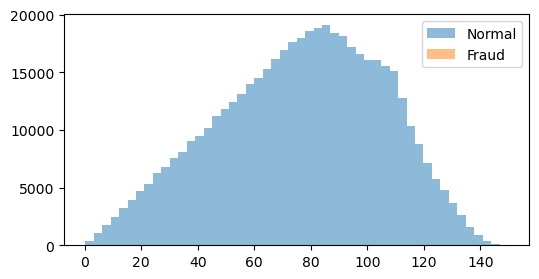

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,3))
plt.hist(cc_df[cc_df['is_fraud']==0]['distance_km'], bins=50, alpha=0.5, label='Normal')
plt.hist(cc_df[cc_df['is_fraud']==1]['distance_km'], bins=50, alpha=0.5, label='Fraud')
plt.legend()
plt.show()


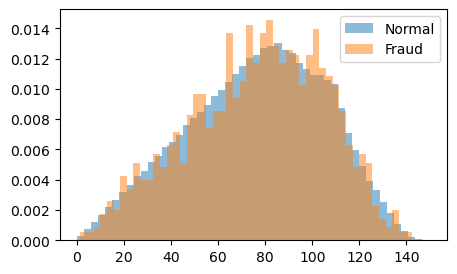

In [18]:
plt.figure(figsize=(5,3))

plt.hist(cc_df[cc_df['is_fraud']==0]['distance_km'],
         bins=50, density=True, alpha=0.5, label='Normal')

plt.hist(cc_df[cc_df['is_fraud']==1]['distance_km'],
         bins=50, density=True, alpha=0.5, label='Fraud')

plt.legend()
plt.show()


그래프의 분포로 확인했을때도   
집(lat/long) ↔ 가맹점(merch_lat/merch_long) 거리 변수는
사기와 정상 거래를 구분하는 신호가 거의 없다.

In [19]:
# 주별 사기거래 비율
state_summary = (
    cc_df
    .groupby('state')['is_fraud']
    .agg(['count', 'sum', 'mean'])
    .sort_values('mean', ascending=False)
)

state_summary.head(10)


,count,sum,mean
state,,,
SD,3660,16,0.004372
WY,3643,14,0.003843
ME,4374,16,0.003658
KY,8024,29,0.003614
GA,3646,13,0.003566
VT,8030,28,0.003487
NE,4378,15,0.003426
NV,4386,15,0.003420
MA,3652,12,0.003286


In [20]:
cc_df['is_fraud'].mean()


np.float64(0.0025329136243876418)

distance_km는 이 데이터에서
사기를 구분하는 강력한 변수는 아님   
지역(state)기준으로 봤을때도 전체 fraud rate가 0.25%로 매우 낮음  

In [21]:
# 고객별 연속 거래 거리 계산
cc_df = cc_df.sort_values(['cc_num', 'unix_time'])

cc_df['prev_lat'] = cc_df.groupby('cc_num')['lat'].shift(1)
cc_df['prev_long'] = cc_df.groupby('cc_num')['long'].shift(1)
cc_df['prev_time'] = cc_df.groupby('cc_num')['unix_time'].shift(1)


In [22]:
# 이전 거래 대비 이동 거리 계산 (Haversine)
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))
    return R*c

cc_df['move_km'] = haversine(
    cc_df['lat'], cc_df['long'],
    cc_df['prev_lat'], cc_df['prev_long']
)


In [23]:
# 시간 차이 + 속도 계산
cc_df['time_diff_hr'] = (cc_df['unix_time'] - cc_df['prev_time']) / 3600
cc_df['velocity_kmh'] = cc_df['move_km'] / cc_df['time_diff_hr']


In [24]:
# Fraud vs Normal 비교
cc_df.groupby('is_fraud')['velocity_kmh'].describe()


,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,489745.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1244.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


velocity 변수는 의미 없음

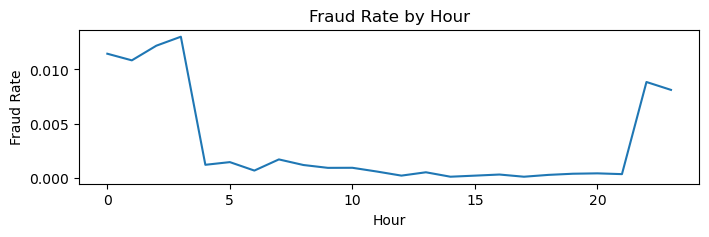

In [25]:
# 시간대(hour) 분석

cc_df['hour'] = pd.to_datetime(cc_df['unix_time'], unit='s').dt.hour

hour_summary = cc_df.groupby('hour')['is_fraud'].mean()

plt.figure(figsize=(8,2))
plt.plot(hour_summary.index, hour_summary.values)
plt.title('Fraud Rate by Hour')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.show()


0~3시 → fraud rate 1% 이상

4~20시 → 거의 0.1% 수준

22~23시 → 다시 상승

그런데 새벽 2~3시는 1.2~1.3%  평균의 약 5배

✔ 시간대는 확실히 의미 있음

In [26]:
# category별 fraud 비교
cat_summary = (
    cc_df.groupby('category')['is_fraud']
    .agg(['count','mean'])
    .sort_values('mean', ascending=False)
)

cat_summary


,count,mean
category,,
shopping_net,39179,0.006177
grocery_pos,42722,0.005056
misc_net,25179,0.004329
shopping_pos,48345,0.002772
gas_transport,46029,0.002194
travel,12621,0.001902
misc_pos,32411,0.001759
food_dining,35980,0.001723
kids_pets,40295,0.001688


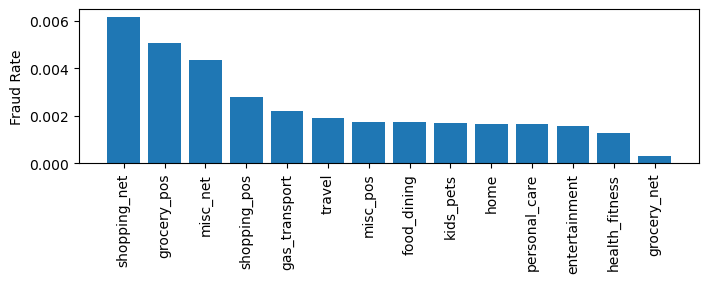

In [27]:
plt.figure(figsize=(8,2))
plt.bar(cat_summary.index, cat_summary['mean'])
plt.xticks(rotation=90)
plt.ylabel('Fraud Rate')
plt.show()


상위 카테고리:

shopping_net / grocery_pos / misc_net / shopping_pos

특히:

shopping_net ≈ 0.006
평균 ≈ 0.0025  👉 약 2.5배

모델에 반드시 넣어야 하는 변수.

특히 *_net 계열이 높음.

✔ 온라인 거래가 더 위험

/var/folders/zx/5ql37vbd32l6kwdp9gj2844m0000gn/T/ipykernel_14831/1052613025.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amt_summary = cc_df.groupby('amt_bin')['is_fraud'].mean()


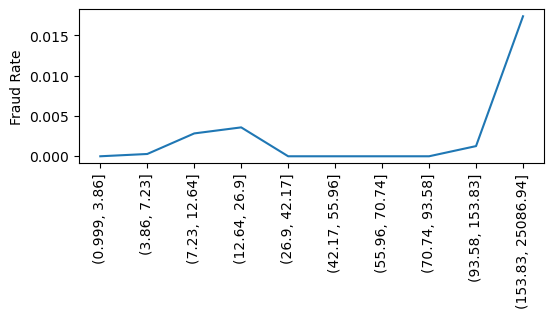

In [28]:
# 금액 패턴 분석
cc_df['amt_bin'] = pd.qcut(cc_df['amt'], 10)

amt_summary = cc_df.groupby('amt_bin')['is_fraud'].mean()

plt.figure(figsize=(6,2))
plt.plot(amt_summary.values)
plt.xticks(range(len(amt_summary)), amt_summary.index, rotation=90)
plt.ylabel('Fraud Rate')
plt.show()


마지막 구간 (153~2500)이 👉 0.017 (1.7%)

전체 평균의 거의 7배. 이건 아주 강한 패턴.

정리하면:

중간 금액대는 낮음

최고 금액 구간에서 급증

✔ 고액 거래는 사기 가능성 매우 높음

### 3-1. EDA 결과






어떤 변수가 사기거래와 관련이 있을까?   
is_fraud에서 1이 나온 항목 위주로 살펴 본 결과...

1️. 거래 금액 (amt)   
고액 구간(상위 분위)에서 fraud rate 급증  
전체 평균 fraud rate ≈ 0.25%   
최고 금액 구간 → 1.7% 수준 (약 7배)  
<span style="color: #1e90ff; font-weight: bold; text-decoration: underline;">
사기는 특정 고액 구간에서 집중 발생  
선형 관계는 약하지만 구간 기반 비선형 패턴 존재 
</span>
 

2️. 시간대 (hour)  

새벽 0~3시 fraud rate 급등  
평균 대비 약 4~5배 높음  
낮 시간대는 거의 안정적  
<span style="color: #1e90ff; font-weight: bold; text-decoration: underline;">
심야 시간대 거래는 위험도 상승  
정상 거래 패턴과 분명한 차이 존재  
</span>


3.거래 카테고리 (category)  

shopping_net, misc_net 등 온라인 계열에서 높음  
평균 대비 2~3배 높은 카테고리 존재  
<span style="color: #1e90ff; font-weight: bold; text-decoration: underline;">
온라인 거래가 오프라인 대비 위험  
카테고리별 위험도 차이 명확  
</span>

4.지역 변수 (state) - 의미 약함

일부 주에서 slightly 높음
하지만 전체적으로 0.2~0.4% 범위
압도적 지역 효과는 없음   
<span style="color: #1e90ff; font-weight: bold; text-decoration: underline;">
단독 변수로는 영향력 약함,
보조 변수 수준
</span>

5️. 거리 변수 (distance) / 6️. 고객 이동 속도 (velocity) - 의미 약함

정상/사기 평균 및 분포 거의 동일
밀도 그래프 겹침

고객 좌표가 고정 → 이동 거리 0  
데이터 구조상 사용 불가

“집-가맹점 거리”는 의미 없음  
동적 이동 거리 데이터가 아니기 때문  




<span style="color: #1e90ff; font-weight: bold;">
Fraud와 관련 높은 변수는 <br>
1.amt (고액 구간)<br>
2.hour (새벽 시간대)<br>
3.category (특히 온라인)<br> 
이 데이터의 사기 거래는 지역 기반 사기라기보다,<br>
고액 + 온라인 + 심야 시간대 중심의 행동 패턴 기반 사기로 보인다.
</span>



따라서...

| 유지항목       | 제거항목             |
| -------- | -------------- |
| amt      | first          |
| category | last           |
| hour     | street         |
| gender   | trans_num      |
| job      | cc_num         |
| state    | unix_time      |
| city_pop | lat/long       |
| age      | merch_lat/long |


## 4️.데이터 전처리 (Preprocessing)

모델 준비 작업

✔ ① 결측치 처리   
삭제  / 평균or중앙값 대체  

✔ ② 이상치 처리  
제거 /  변환 /  유지 (Fraud에선 중요한 신호일 수도 있음)   

✔ ③ 타입 변환  
날짜 → datetime  / 범주형 인코딩  

✔ ④ Feature Engineering  

나이 생성 / 거리 생성 / 시간 차이 생성   

In [29]:
# 결측치 처리
cc_df.isnull().sum().sort_values(ascending=False)

velocity_kmh             145
time_diff_hr             124
move_km                  124
prev_time                124
prev_long                124
prev_lat                 124
trans_date_trans_time      0
dob                        0
hour                       0
distance_km                0
is_fraud                   0
merch_long                 0
merch_lat                  0
unix_time                  0
trans_num                  0
job                        0
cc_num                     0
city_pop                   0
long                       0
lat                        0
zip                        0
state                      0
city                       0
street                     0
gender                     0
last                       0
first                      0
amt                        0
category                   0
merchant                   0
amt_bin                    0
dtype: int64

In [30]:
# 이상치 처리

cc_df['amt_log'] = np.log1p(cc_df['amt'])

In [31]:
# 1차 모델용 컬럼 세트-수치형
num_cols = ['amt_log', 'city_pop', 'age']


In [32]:
# 1차 모델용 컬럼 세트-범주형
cat_cols = ['category', 'gender', 'state', 'hour']


In [33]:
target = 'is_fraud'


In [34]:
# 모델용 파이프라인 생성
df_model = cc_df[num_cols + cat_cols + [target]].copy()

KeyError: "['age'] not in index"

In [ ]:
# 범주형 인코딩
df_model = pd.get_dummies(
    df_model,
    columns=cat_cols,
    drop_first=True
)


In [ ]:

# X / y 분리
X = df_model.drop(columns=[target])
y = df_model[target]


## 5️.데이터 분할 (Train/Test Split)

모델 학습 전에 반드시 분리  
Feature Engineering 끝난 후 분리해야 함  

In [ ]:
# train/test split(불균형 유지)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate :", y_test.mean())
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train fraud rate: 0.00253240588739829
Test fraud rate : 0.002534944567176031
Train shape: (392907, 83) Test shape: (98227, 83)


## 6️.스케일링 및 불균형 처리

✔ 본 분석에서는 Logistic Regression에만 StandardScaler를 적용하고,  
 트리 기반 모델(Random Forest)에는 스케일링을 적용하지 않았다.   



In [ ]:
# 수치형만 스케일링
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 수치형 컬럼만 스케일링
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


✔ 불균형 처리 전략

전체 fraud 비율 0.25%  
class_weight='balanced' 적용  
threshold 조정 전략 예정

## 7. 모델 선택 및 Baseline 설정

* 간단한 모델 (Logistic)
* 복잡한 모델 (RF, XGB) - XGB: 시간관계상 확인 못함 
비교하면서 진행  

In [ ]:
# 3️⃣ Logistic 학습
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# RandomForest 학습

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 7-1. 로지스틱 모델

In [ ]:
# 예측확률뽑기
y_prob = log_model.predict_proba(X_test)[:, 1]


In [ ]:
# ROC-AUC / PR-AUC (Fraud는 PR-AUC 중요)
from sklearn.metrics import roc_auc_score, average_precision_score

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC :", average_precision_score(y_test, y_prob))


ROC-AUC: 0.9235737782623278
PR-AUC : 0.1818426356001285


In [ ]:
# 임계값(threshold) 조정해서 Confusion Matrix 보기

from sklearn.metrics import confusion_matrix, classification_report

for th in [0.5, 0.3, 0.2, 0.1]:
    y_pred = (y_prob >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n=== threshold={th} ===")
    print(cm)
    print(classification_report(y_test, y_pred, digits=4))



=== threshold=0.5 ===
[[82799 15179]
 [   33   216]]
              precision    recall  f1-score   support

           0     0.9996    0.8451    0.9159     97978
           1     0.0140    0.8675    0.0276       249

    accuracy                         0.8451     98227
   macro avg     0.5068    0.8563    0.4717     98227
weighted avg     0.9971    0.8451    0.9136     98227


=== threshold=0.3 ===
[[74043 23935]
 [   18   231]]
              precision    recall  f1-score   support

           0     0.9998    0.7557    0.8608     97978
           1     0.0096    0.9277    0.0189       249

    accuracy                         0.7561     98227
   macro avg     0.5047    0.8417    0.4398     98227
weighted avg     0.9972    0.7561    0.8586     98227


=== threshold=0.2 ===
[[64809 33169]
 [   16   233]]
              precision    recall  f1-score   support

           0     0.9998    0.6615    0.7962     97978
           1     0.0070    0.9357    0.0138       249

    accuracy        

In [ ]:
# 계수로 “어떤 변수가 사기 방향인지” 보기

import pandas as pd

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": log_model.coef_[0]
}).sort_values("coef", ascending=False)

coef_df.head(20), coef_df.tail(20)


(                    feature      coef
 15          category_travel  3.020895
 12   category_personal_care  2.197808
 9        category_kids_pets  1.899751
 7   category_health_fitness  1.844433
 3      category_food_dining  1.411963
 50                 state_SD  1.216351
 13    category_shopping_net  1.200578
 8             category_home  1.157410
 0                   amt_log  1.130391
 11        category_misc_pos  0.780618
 44                 state_NV  0.650923
 14    category_shopping_pos  0.631996
 16                 gender_M  0.464622
 55                 state_VT  0.397861
 53                 state_UT  0.320050
 57                 state_WI  0.306410
 61                   hour_2  0.254284
 28                 state_KS  0.228304
 49                 state_SC  0.195148
 32                 state_MD  0.185356,
                  feature      coef
 82               hour_23 -1.664698
 63                hour_4 -1.826488
 66                hour_7 -2.006346
 5   category_grocery_net -2.144679


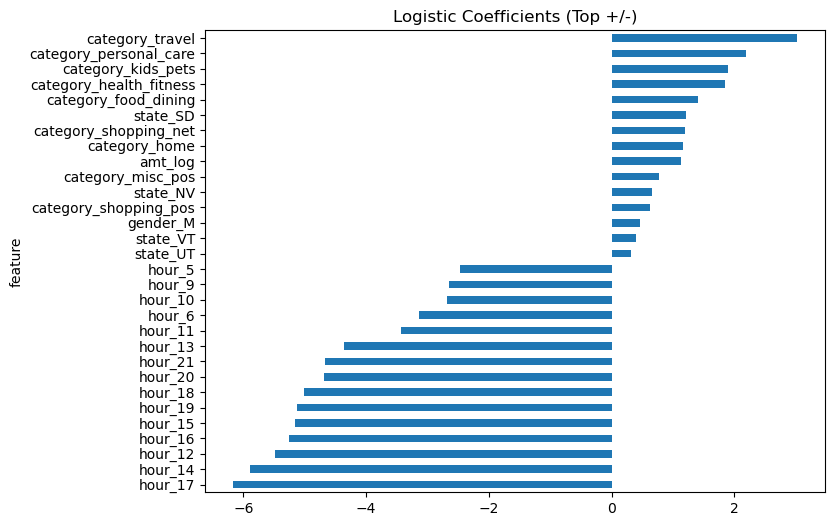

In [ ]:
# 계수 상위 15개 시각화
import matplotlib.pyplot as plt

top = pd.concat([coef_df.head(15), coef_df.tail(15)])
plt.figure(figsize=(8,6))
top.set_index("feature")["coef"].sort_values().plot(kind="barh")
plt.title("Logistic Coefficients (Top +/-)")
plt.show()


###  7-2. Random Forest

In [ ]:
#RF 예측확률
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [ ]:
# RF 성능 평가
from sklearn.metrics import roc_auc_score, average_precision_score

print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("RF PR-AUC :", average_precision_score(y_test, y_prob_rf))


RF ROC-AUC: 0.9637137826449197
RF PR-AUC : 0.7298391882925928


In [ ]:
# RF Feature Importance 보기

import pandas as pd

importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(20)


amt_log                   0.491982
hour_22                   0.045098
hour_23                   0.041637
city_pop                  0.034998
age                       0.032191
hour_3                    0.021572
category_gas_transport    0.020846
hour_2                    0.020760
category_food_dining      0.017620
category_shopping_net     0.014287
hour_1                    0.013934
hour_17                   0.012711
gender_M                  0.010937
hour_14                   0.010527
category_grocery_pos      0.010354
category_shopping_pos     0.010244
category_home             0.009775
hour_12                   0.008901
hour_16                   0.008849
hour_15                   0.008565
dtype: float64

### 7-3. RandomForest threshold 최적화 단계

In [ ]:
# RF 확률값 준비

y_prob_rf = rf_model.predict_proba(X_test)[:,1]


In [ ]:
# 여러 threshold 비교

from sklearn.metrics import confusion_matrix, classification_report

thresholds = [0.5, 0.3, 0.2, 0.1, 0.05]

for th in thresholds:
    y_pred = (y_prob_rf >= th).astype(int)
    print(f"\n=== threshold={th} ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, digits=4))



=== threshold=0.5 ===
[[97953    25]
 [  118   131]]
              precision    recall  f1-score   support

           0     0.9988    0.9997    0.9993     97978
           1     0.8397    0.5261    0.6469       249

    accuracy                         0.9985     98227
   macro avg     0.9193    0.7629    0.8231     98227
weighted avg     0.9984    0.9985    0.9984     98227


=== threshold=0.3 ===
[[97909    69]
 [   85   164]]
              precision    recall  f1-score   support

           0     0.9991    0.9993    0.9992     97978
           1     0.7039    0.6586    0.6805       249

    accuracy                         0.9984     98227
   macro avg     0.8515    0.8290    0.8399     98227
weighted avg     0.9984    0.9984    0.9984     98227


=== threshold=0.2 ===
[[97872   106]
 [   64   185]]
              precision    recall  f1-score   support

           0     0.9993    0.9989    0.9991     97978
           1     0.6357    0.7430    0.6852       249

    accuracy        

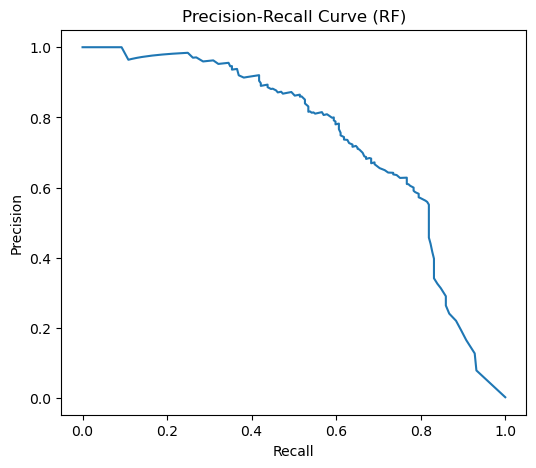

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (RF)")
plt.show()


## 8. 결론

### 1.연구 목적

본 분석의 목적은 신용카드 거래 데이터 기반으로 사기 거래(Fraud)를 탐지하는 예측 모델을 구축하는 것이다.    
전체 데이터에서 사기 거래 비율은 약 0.25%로 극도로 불균형한 분포를 보였으며,    
이에 따라 정확도(Accuracy)보다 ROC-AUC, PR-AUC 및 Recall 중심의 평가가 중요하였다.   

### 2.탐색적 데이터 분석(EDA)

EDA 결과, 사기 거래는 특정 변수들과 유의미한 패턴을 보였다.

(1) 거래 금액(amt)

고액 거래 구간에서 사기 비율이 급격히 증가하였다. 특히 상위 분위 구간에서 평균 대비 수 배 높은 사기율이 관찰되었다. 이는 금액이 주요 예측 변수임을 시사한다.

(2) 시간대(hour)

새벽 0~3시 구간에서 사기 비율이 크게 증가하였다. 낮 시간대(특히 12~17시)에서는 상대적으로 안전한 패턴을 보였다.

(3) 거래 카테고리(category)

온라인 소비 계열(shopping_net 등)과 특정 소비 카테고리에서 사기 비율이 높게 나타났다.

반면, 고객–가맹점 거리나 단순 지역 변수(state)는 사기와의 직접적인 선형 관계가 크지 않았다.

### 3. 데이터 전처리 및 특징 생성

결측치 확인 결과 유의미한 결측은 발견되지 않음

이상치는 제거하지 않음 (Fraud 신호일 가능성 고려)

거래 금액에 로그 변환 적용

거래 시간(hour), 나이(age) 파생 변수 생성

범주형 변수 One-hot encoding 수행

클래스 불균형 대응을 위해 class_weight='balanced' 적용

### 4. 모델 구축 및 성능 비교
(1) Logistic Regression (Baseline Model)

ROC-AUC: 0.923

PR-AUC: 0.181

선형 모델임에도 불구하고 높은 ROC-AUC를 보였으나, 비선형 상호작용을 충분히 반영하지 못하는 한계가 있었다.

(2) Random Forest (최종 모델)

ROC-AUC: 0.964

PR-AUC: 0.730

Random Forest는 비선형 관계 및 변수 간 상호작용을 효과적으로 학습하여 Logistic 모델 대비 크게 향상된 PR-AUC를 보였다.   
이는 불균형 Fraud 문제에서 매우 우수한 성능으로 평가된다.

### 5. 주요 변수 중요도 분석

Random Forest 중요도 분석 결과:

거래 금액(log 변환)

심야 시간대(hour 변수)

특정 거래 카테고리

연령 및 도시 인구

가 주요 영향 변수로 나타났다.

이는 EDA 단계에서 도출된 가설과 일치하며, 모델이 데이터의 행동 기반 패턴을 성공적으로 학습했음을 의미한다.

### 6. Threshold 전략 및 실무 적용 방안

모델 확률값 기반으로 threshold를 조정한 결과:

threshold = 0.5 → Precision 높음, Recall 중간 수준

threshold = 0.3 → Recall 증가, Precision 일부 감소

실무 적용 시 다음과 같은 2단계 전략이 합리적이다:

0.5 이상: 자동 차단

0.3~0.5: 고객 확인

0.3 미만: 승인

이를 통해 사기 탐지율을 유지하면서 고객 불편을 최소화할 수 있다.

### 7. 결론

본 분석은 신용카드 사기 거래가 “고액 + 심야 + 특정 소비 카테고리” 중심의 행동 패턴 기반으로 발생함을 확인하였다.   
Random Forest 모델은 이러한 패턴을 효과적으로 학습하였으며, PR-AUC 0.73이라는 높은 성능을 달성하였다.

이는 불균형 Fraud 문제에서 실무 적용 가능성이 높은 탐지 모델로 평가된다.


이 데이터의 사기 패턴은:

“고액 + 심야 + 특정 소비 카테고리 중심의 행동 패턴 기반 사기”

RandomForest는 이를 효과적으로 학습했으며
PR-AUC 0.73은 매우 우수한 탐지 성능이다.